### LSTM 

In [221]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import ast

In [222]:


HORIZON = 72
SEQ_LEN = 48
EPOCHS = 100


df_main = pd.read_csv("final_data.csv")
df_main["datetime"] = pd.to_datetime(df_main["datetime"])

dk = pd.read_csv("hourly_data_Danmark_55.99775695800781_10.0052490234375.csv")
ring = pd.read_csv("hourly_data_Ringsted_56.1740608215332_9.545852661132812.csv")
silk = pd.read_csv("hourly_data_Silkeborg_55.444580078125_11.78314208984375.csv")

for df in [dk, ring, silk]:
    df["date"] = pd.to_datetime(df["date"])

dk = dk.add_prefix("dk_").rename(columns={"dk_date": "datetime"})
ring = ring.add_prefix("ring_").rename(columns={"ring_date": "datetime"})
silk = silk.add_prefix("silk_").rename(columns={"silk_date": "datetime"})

df = df_main.merge(dk, on="datetime", how="left")
df = df.merge(ring, on="datetime", how="left")
df = df.merge(silk, on="datetime", how="left")

df = df.sort_values("datetime")
print("before", len(df))

df["hour"] = df["datetime"].dt.hour

df["lag_1"] = df["value_spot"].shift(1)
df["lag_2"] = df["value_spot"].shift(2)
df["lag_24"] = df["value_spot"].shift(24)

df = df.ffill()



df = pd.get_dummies(df, columns=[c for c in ["zone_prev", "zone"] if c in df.columns], drop_first=True)

# IMPORT
df["import"] = df["import"].apply(ast.literal_eval)
import_expanded = df["import"].apply(pd.Series).add_prefix("import_")

# EXPORT
df["export"] = df["export"].apply(ast.literal_eval)
export_expanded = df["export"].apply(pd.Series).add_prefix("export_")

# Combine everything
df = pd.concat(
    [df.drop(columns=["import", "export"]), import_expanded, export_expanded],
    axis=1
)



df["mix"] = df["mix"].apply(ast.literal_eval)
expanded = df["mix"].apply(pd.Series)
df = pd.concat([df.drop(columns=["mix"]), expanded], axis=1)



df = df.join(df["flows"].apply(pd.Series))

df = df.fillna(0)

df = df.drop(columns=["emissionFactorType", "battery storage", "hydro storage", "flows", "unit_spot", "unit_total_load"])




before 34994


In [223]:
df["value_spot"].describe()

count    34994.000000
mean       149.466225
std        128.188643
min       -440.100000
25%         70.080000
50%        112.870000
75%        193.722500
max        871.000000
Name: value_spot, dtype: float64

In [224]:
for i in range(1, HORIZON + 1):
    df[f"price_t+{i}"] = df["value_spot"].shift(-i)
    df[f"carbon_t+{i}"] = df["carbonIntensity"].shift(-i)

hours = df["hour"].values
df = df.drop(columns=["datetime"], errors="ignore")
df = df.dropna()

target_cols = (
    [f"price_t+{i}" for i in range(1, HORIZON + 1)] +
    [f"carbon_t+{i}" for i in range(1, HORIZON + 1)]
)

X = df.drop(columns=target_cols).values
Y = df[target_cols].values
hours = hours[-len(X):]


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
Y_train, Y_val, Y_test = Y[:split1], Y[split1:split2], Y[split2:]
h_train, h_val, h_test = hours[:split1], hours[split1:split2], hours[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences_12(X, Y, hours, seq_len=48):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len - HORIZON):
        if hours[i + seq_len - 1] != 12:
            continue

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

X_train, Y_train = create_sequences_12(X_train, Y_train, h_train, SEQ_LEN)
X_val, Y_val = create_sequences_12(X_val, Y_val, h_val, SEQ_LEN)
X_test, Y_test = create_sequences_12(X_test, Y_test, h_test, SEQ_LEN)

/var/folders/47/tm461bpn1bn2r8cqz3v19h7r0000gp/T/ipykernel_8530/4048923525.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"carbon_t+{i}"] = df["carbonIntensity"].shift(-i)
/var/folders/47/tm461bpn1bn2r8cqz3v19h7r0000gp/T/ipykernel_8530/4048923525.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"price_t+{i}"] = df["value_spot"].shift(-i)


In [243]:
print(X[:5])

[[41.33 1974 136 0 2022 70.34300231933594 77.24 14.440443 29.914679
  28.682009 0.0 265.71094 267.24094 272.20255 0.0 0.0 0.0 13.358861
  29.370352 26.984175 0.0 255.96373 258.6901 263.74606 0.0 0.0 0.0
  15.484185 34.875435 27.597643 0.0 268.66782 277.7118 273.05283 0.0 0.0
  0.0 0.0 0.0 0.0 426.0 400.0 0.0 0.0 0.0 0.0 0.0 0.0 483.0 618.0 1110.0
  0.0 0.0 0.0 0.0 0.0 0 0 305.0 177.0 2003.0 1.0 1.0 141.0 11.0 2.0 1728
  1309 0.0 1.0 -0.9749279121818236 -0.2225209339563146 0.0 1.0]
 [43.22 1934 139 1 2022 70.34300231933594 77.24 13.004921 27.0024
  26.826101 0.0 265.23645 269.2361 269.21518 0.0 0.0 0.0 12.43434
  27.534704 25.399021 0.0 247.8905 258.6901 255.76268 0.0 0.0 0.0
  17.414476 32.491867 30.269197 0.0 277.1249 279.56662 280.49142 0.0 0.0
  0.0 42.18 41.33 0.0 299.0 395.0 0.0 0.0 0.0 0.0 0.0 0.0 569.0 560.0
  1110.0 0.0 0.0 0.0 0.0 0.0 0 0 344.0 177.0 1884.0 1.0 1.0 129.0 11.0
  2.0 1670 1262 0.25881904510252074 0.9659258262890683
  -0.9749279121818236 -0.2225209339563146 0.0 1

In [225]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, HORIZON * 2)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel(X_train.shape[2])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [226]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
counter = 0
best_weights = None
patience = 2

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model(Xb).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

price_pred = preds[:, :24]
carbon_pred = preds[:, 24:]

price_true = actuals[:, :24]
carbon_true = actuals[:, 24:]

print("\nFINAL RESULTS")
print(f"Price MAE: {np.mean(np.abs(price_pred - price_true)):.2f}")
print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")


Epoch 1, Train: 691072.29, Val: 39738.09
Epoch 2, Train: 666039.60, Val: 32263.55
Epoch 3, Train: 570606.47, Val: 18106.04
Epoch 4, Train: 425153.64, Val: 7600.63
Epoch 5, Train: 286600.42, Val: 12751.18
Epoch 6, Train: 211637.49, Val: 30166.83
Epoch 7, Train: 195225.31, Val: 38469.99
Epoch 8, Train: 193548.44, Val: 36987.22
Epoch 9, Train: 192977.82, Val: 35119.32
Epoch 10, Train: 192063.47, Val: 35343.06
Epoch 11, Train: 193100.35, Val: 35362.21
Epoch 12, Train: 192640.73, Val: 36137.23
Epoch 13, Train: 192541.45, Val: 35066.15
Epoch 14, Train: 192718.66, Val: 33843.04
Epoch 15, Train: 189941.19, Val: 32998.86
Epoch 16, Train: 175821.15, Val: 12663.37
Epoch 17, Train: 154061.77, Val: 10221.24
Epoch 18, Train: 136382.59, Val: 8718.73
Epoch 19, Train: 124781.23, Val: 9766.95
Epoch 20, Train: 118131.92, Val: 8238.94
Epoch 21, Train: 114410.70, Val: 8418.67
Epoch 22, Train: 111071.48, Val: 8387.27
Epoch 23, Train: 108809.44, Val: 8859.17
Epoch 24, Train: 107067.57, Val: 8896.82
Epoch 25,

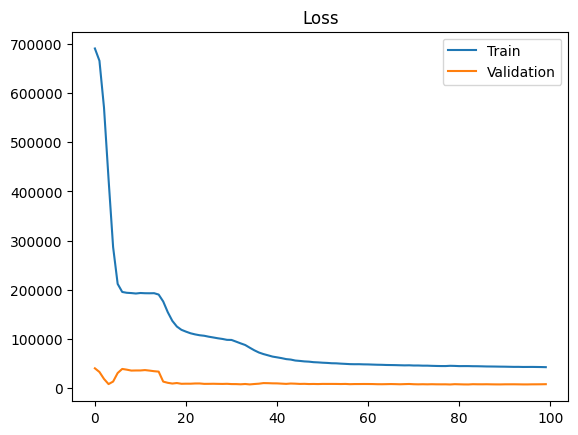

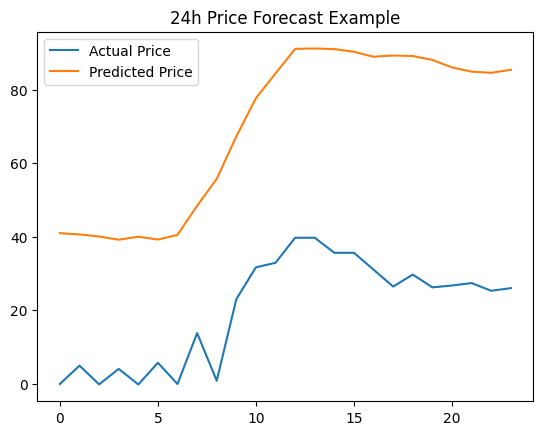

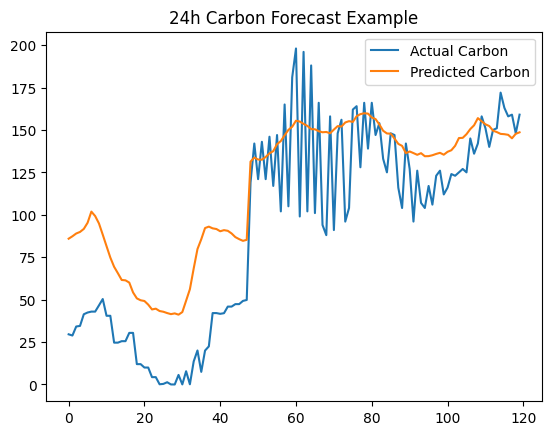

In [227]:
# Loss curves
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

#example plot
idx = 200

plt.figure()
plt.plot(price_true[idx], label="Actual Price")
plt.plot(price_pred[idx], label="Predicted Price")
plt.legend()
plt.title("24h Price Forecast Example")
plt.show()

plt.figure()
plt.plot(carbon_true[idx], label="Actual Carbon")
plt.plot(carbon_pred[idx], label="Predicted Carbon")
plt.legend()
plt.title("24h Carbon Forecast Example")
plt.show()

In [228]:


HORIZON = 24
SEQ_LEN = 48
EPOCHS = 100


df_main = pd.read_csv("final_data.csv")
df_main["datetime"] = pd.to_datetime(df_main["datetime"])

dk = pd.read_csv("hourly_data_Danmark_55.99775695800781_10.0052490234375.csv")
ring = pd.read_csv("hourly_data_Ringsted_56.1740608215332_9.545852661132812.csv")
silk = pd.read_csv("hourly_data_Silkeborg_55.444580078125_11.78314208984375.csv")

for df in [dk, ring, silk]:
    df["date"] = pd.to_datetime(df["date"])

dk = dk.add_prefix("dk_").rename(columns={"dk_date": "datetime"})
ring = ring.add_prefix("ring_").rename(columns={"ring_date": "datetime"})
silk = silk.add_prefix("silk_").rename(columns={"silk_date": "datetime"})

df = df_main.merge(dk, on="datetime", how="left")
df = df.merge(ring, on="datetime", how="left")
df = df.merge(silk, on="datetime", how="left")

df = df.sort_values("datetime")
print("before", len(df))

df["hour"] = df["datetime"].dt.hour

df["lag_1"] = df["value_spot"].shift(1)
df["lag_2"] = df["value_spot"].shift(2)
df["lag_24"] = df["value_spot"].shift(24)

df = df.ffill()



df = pd.get_dummies(df, columns=[c for c in ["zone_prev", "zone"] if c in df.columns], drop_first=True)

# IMPORT
df["import"] = df["import"].apply(ast.literal_eval)
import_expanded = df["import"].apply(pd.Series).add_prefix("import_")

# EXPORT
df["export"] = df["export"].apply(ast.literal_eval)
export_expanded = df["export"].apply(pd.Series).add_prefix("export_")

# Combine everything
df = pd.concat(
    [df.drop(columns=["import", "export"]), import_expanded, export_expanded],
    axis=1
)



df["mix"] = df["mix"].apply(ast.literal_eval)
expanded = df["mix"].apply(pd.Series)
df = pd.concat([df.drop(columns=["mix"]), expanded], axis=1)



df = df.join(df["flows"].apply(pd.Series))

df = df.fillna(0)

df = df.drop(columns=["emissionFactorType", "battery storage", "hydro storage", "flows", "unit_spot", "unit_total_load"])




df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["weekday_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["weekday_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

df["month_sin"] = np.sin(2 * np.pi * (df["month"] -1) / 12)
df["month_cos"] = np.cos(2 * np.pi * (df["month"] -1)/ 12)

before 34994


In [229]:
for i in range(1, HORIZON + 1):
    df[f"price_t+{i}"] = df["value_spot"].shift(-i)

hours = df["hour"].values
df = df.drop(columns=["datetime"], errors="ignore")
df = df.dropna()

target_cols = (
    [f"price_t+{i}" for i in range(1, HORIZON + 1)] 
)

drop_cols = ["hour", "day_of_week","month"]

X = df.drop(columns=target_cols+drop_cols).values
Y = df[target_cols].values
hours = hours[-len(X):]


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
Y_train, Y_val, Y_test = Y[:split1], Y[split1:split2], Y[split2:]
h_train, h_val, h_test = hours[:split1], hours[split1:split2], hours[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences_12(X, Y, hours, seq_len=48):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len - HORIZON):
        if hours[i + seq_len - 1] != 12:
            continue

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

X_train, Y_train = create_sequences_12(X_train, Y_train, h_train, SEQ_LEN)
X_val, Y_val = create_sequences_12(X_val, Y_val, h_val, SEQ_LEN)
X_test, Y_test = create_sequences_12(X_test, Y_test, h_test, SEQ_LEN)

In [230]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 48, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(48, 128),
            nn.ReLU(),
            nn.Linear(128, 24)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel(X_train.shape[2])

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [231]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
counter = 0
best_weights = None
patience = 15

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break


    if best_weights is not None:
        model.load_state_dict(best_weights)

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model(Xb).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

price_pred = preds[:, :24]
carbon_pred = preds[:, 24:]

price_true = actuals[:, :24]
carbon_true = actuals[:, 24:]

print("\nFINAL RESULTS")
print(f"Price MAE: {np.mean(np.abs(price_pred - price_true)):.2f}")
print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")


Epoch 1, Train: 2757.70, Val: 302.38
Epoch 2, Train: 2736.73, Val: 289.52
Epoch 3, Train: 2641.15, Val: 259.34
Epoch 4, Train: 2470.04, Val: 216.83
Epoch 5, Train: 2246.20, Val: 168.83
Epoch 6, Train: 1994.47, Val: 129.90
Epoch 7, Train: 1764.10, Val: 139.47
Epoch 8, Train: 1624.69, Val: 195.39
Epoch 9, Train: 1572.75, Val: 236.85
Epoch 10, Train: 1556.38, Val: 254.06
Epoch 11, Train: 1554.10, Val: 261.93
Epoch 12, Train: 1502.54, Val: 198.13
Epoch 13, Train: 1355.80, Val: 137.86
Epoch 14, Train: 1194.86, Val: 106.89
Epoch 15, Train: 1045.23, Val: 100.41
Epoch 16, Train: 937.66, Val: 99.00
Epoch 17, Train: 853.39, Val: 102.44
Epoch 18, Train: 783.46, Val: 97.38
Epoch 19, Train: 726.08, Val: 97.89
Epoch 20, Train: 675.80, Val: 100.87
Epoch 21, Train: 646.27, Val: 100.34
Epoch 22, Train: 637.62, Val: 102.48
Epoch 23, Train: 611.96, Val: 101.19
Epoch 24, Train: 602.66, Val: 99.35
Epoch 25, Train: 593.46, Val: 100.78
Epoch 26, Train: 578.83, Val: 100.77
Epoch 27, Train: 571.77, Val: 101.55

/Users/ludviglindmark/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/Kandidat/Advanced BA/Advanced_business_analytics/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ludviglindmark/Library/CloudStorage/OneDrive-DanmarksTekniskeUniversitet/Kandidat/Advanced BA/Advanced_business_analytics/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


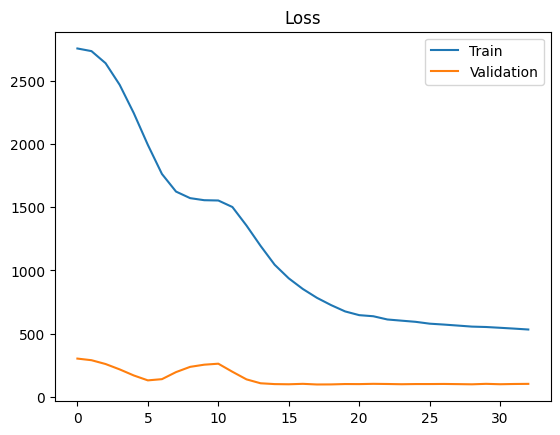

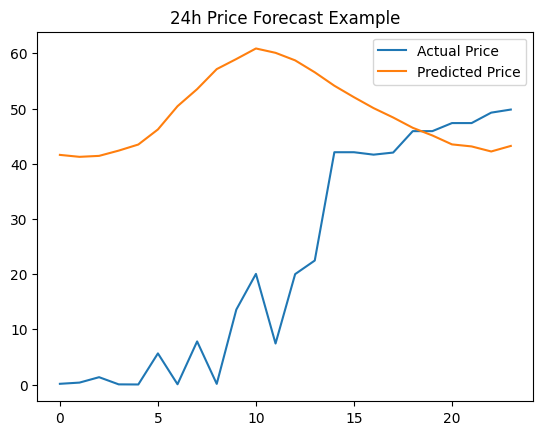

In [232]:
# Loss curves
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

#example plot
idx = 200

plt.figure()
plt.plot(price_true[idx], label="Actual Price")
plt.plot(price_pred[idx], label="Predicted Price")
plt.legend()
plt.title("24h Price Forecast Example")
plt.show()


In [233]:
for i in range(1, HORIZON + 1):
    df[f"carbon_t+{i}"] = df["carbonIntensity"].shift(-i)

hours = df["hour"].values
df = df.drop(columns=["datetime"], errors="ignore")
df = df.dropna()

target_cols = (
    [f"carbon_t+{i}" for i in range(1, HORIZON + 1)] 
)

drop_cols = ["hour", "day_of_week","month"]

X = df.drop(columns=target_cols+drop_cols).values
Y = df[target_cols].values
hours = hours[-len(X):]


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
Y_train, Y_val, Y_test = Y[:split1], Y[split1:split2], Y[split2:]
h_train, h_val, h_test = hours[:split1], hours[split1:split2], hours[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences_12(X, Y, hours, seq_len=48):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len - HORIZON):
        if hours[i + seq_len - 1] != 12:
            continue

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

X_train, Y_train = create_sequences_12(X_train, Y_train, h_train, SEQ_LEN)
X_val, Y_val = create_sequences_12(X_val, Y_val, h_val, SEQ_LEN)
X_test, Y_test = create_sequences_12(X_test, Y_test, h_test, SEQ_LEN)

/var/folders/47/tm461bpn1bn2r8cqz3v19h7r0000gp/T/ipykernel_8530/863059002.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"carbon_t+{i}"] = df["carbonIntensity"].shift(-i)


In [234]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 48, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(48, 256),
            nn.ReLU(),
            nn.Linear(256, 24)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel(X_train.shape[2])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [235]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
counter = 0
best_weights = None
patience = 2

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break


    if best_weights is not None:
        model.load_state_dict(best_weights)

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model(Xb).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

carbon_pred = preds[:, :24]

carbon_true = actuals[:, :24]

print("\nFINAL RESULTS")
print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")


Epoch 1, Train: 572383.91, Val: 46985.76
Epoch 2, Train: 553818.00, Val: 40948.52
Epoch 3, Train: 487689.00, Val: 28153.17
Epoch 4, Train: 377790.03, Val: 14093.23
Epoch 5, Train: 255516.36, Val: 6100.38
Epoch 6, Train: 157853.77, Val: 9581.67
Epoch 7, Train: 108772.65, Val: 19945.17
Early stopping

FINAL RESULTS
Carbon MAE: 73.50


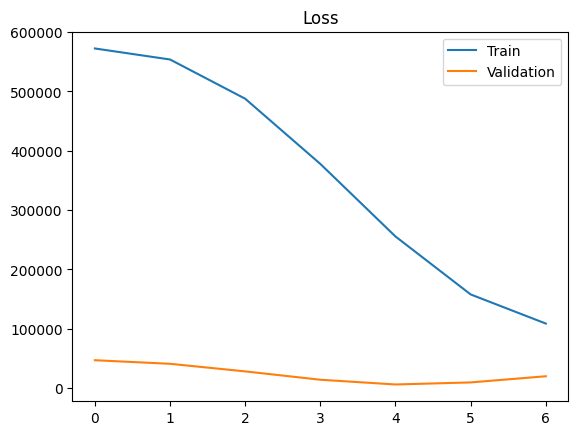

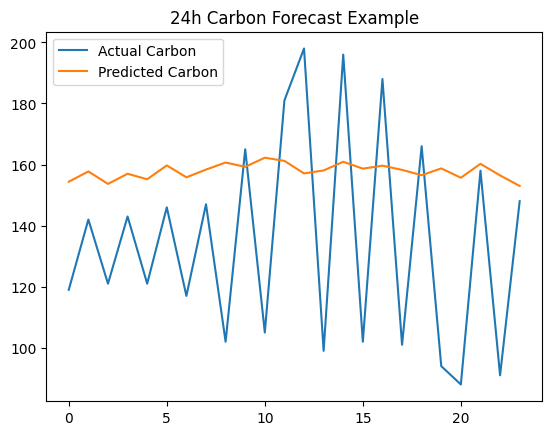

In [236]:
# Loss curves
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

#example plot
idx = 200

plt.figure()
plt.plot(carbon_true[idx], label="Actual Carbon")
plt.plot(carbon_pred[idx], label="Predicted Carbon")
plt.legend()
plt.title("24h Carbon Forecast Example")
plt.show()

In [ ]:


HORIZON = 72
SEQ_LEN = 48
EPOCHS = 100


df_main = pd.read_csv("final_data.csv")
df_main["datetime"] = pd.to_datetime(df_main["datetime"])

dk = pd.read_csv("hourly_data_Danmark_55.99775695800781_10.0052490234375.csv")
ring = pd.read_csv("hourly_data_Ringsted_56.1740608215332_9.545852661132812.csv")
silk = pd.read_csv("hourly_data_Silkeborg_55.444580078125_11.78314208984375.csv")

for df in [dk, ring, silk]:
    df["date"] = pd.to_datetime(df["date"])

dk = dk.add_prefix("dk_").rename(columns={"dk_date": "datetime"})
ring = ring.add_prefix("ring_").rename(columns={"ring_date": "datetime"})
silk = silk.add_prefix("silk_").rename(columns={"silk_date": "datetime"})

df = df_main.merge(dk, on="datetime", how="left")
df = df.merge(ring, on="datetime", how="left")
df = df.merge(silk, on="datetime", how="left")

df = df.sort_values("datetime")
print("before", len(df))

df_z1 = df[df["zone"] == "DK-DK1"].copy()

df_z1["hour"] = df_z1["datetime"].dt.hour

df_z1["lag_1"] = df_z1["value_spot"].shift(1)
df_z1["lag_2"] = df_z1["value_spot"].shift(2)
df_z1["lag_24"] = df_z1["value_spot"].shift(24)

df_z1 = df_z1.ffill()




# IMPORT
df_z1["import"] = df_z1["import"].apply(ast.literal_eval)
import_expanded = df_z1["import"].apply(pd.Series).add_prefix("import_")

# EXPORT
df_z1["export"] = df_z1["export"].apply(ast.literal_eval)
export_expanded = df_z1["export"].apply(pd.Series).add_prefix("export_")

# Combine everything
df_z1 = pd.concat(
    [df_z1.drop(columns=["import", "export"]), import_expanded, export_expanded],
    axis=1
)



df_z1["mix"] = df_z1["mix"].apply(ast.literal_eval)
expanded = df_z1["mix"].apply(pd.Series)
df_z1 = pd.concat([df_z1.drop(columns=["mix"]), expanded], axis=1)



df_z1 = df_z1.join(df_z1["flows"].apply(pd.Series))

df_z1 = df_z1.fillna(0)

df_z1 = df_z1.drop(columns=["emissionFactorType", "battery storage", "hydro storage", "flows", "unit_spot", "unit_total_load"])




df_z1["hour_sin"] = np.sin(2 * np.pi * df_z1["hour"] / 24)
df_z1["hour_cos"] = np.cos(2 * np.pi * df_z1["hour"] / 24)

df_z1["weekday_sin"] = np.sin(2 * np.pi * df_z1["day_of_week"] / 7)
df_z1["weekday_cos"] = np.cos(2 * np.pi * df_z1["day_of_week"] / 7)

df_z1["month_sin"] = np.sin(2 * np.pi * (df_z1["month"] -1) / 12)
df_z1["month_cos"] = np.cos(2 * np.pi * (df_z1["month"] -1)/ 12)


before 34994


In [249]:
for i in range(1, HORIZON + 1):
    df_z1[f"price_t+{i}"] = df_z1["value_spot"].shift(-i)

hours = df_z1["hour"].values
df_z1 = df_z1.drop(columns=["datetime"], errors="ignore")
df_z1 = df_z1.dropna()

target_cols = (
    [f"price_t+{i}" for i in range(1, HORIZON + 1)] 
)

drop_cols = ["hour", "day_of_week","month","zone"]

X = df_z1.drop(columns=target_cols+drop_cols).values
Y = df_z1[target_cols].values
hours = hours[-len(X):]


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
Y_train, Y_val, Y_test = Y[:split1], Y[split1:split2], Y[split2:]
h_train, h_val, h_test = hours[:split1], hours[split1:split2], hours[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences_12(X, Y, hours, seq_len=48):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len - HORIZON):
        if hours[i + seq_len - 1] != 12:
            continue

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

X_train, Y_train = create_sequences_12(X_train, Y_train, h_train, SEQ_LEN)
X_val, Y_val = create_sequences_12(X_val, Y_val, h_val, SEQ_LEN)
X_test, Y_test = create_sequences_12(X_test, Y_test, h_test, SEQ_LEN)

In [250]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 24)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel(X_train.shape[2])

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [253]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
counter = 0
best_weights = None
patience = 15

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break


    if best_weights is not None:
        model.load_state_dict(best_weights)

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model(Xb).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

price_pred = preds[:, :24]
carbon_pred = preds[:, 24:]

price_true = actuals[:, :24]
carbon_true = actuals[:, 24:]

print("\nFINAL RESULTS")
print(f"Price MAE: {np.mean(np.abs(price_pred - price_true)):.2f}")
print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")


Epoch 1, Train: 779.76, Val: 141.04
Epoch 2, Train: 775.58, Val: 145.86
Epoch 3, Train: 775.13, Val: 145.66
Epoch 4, Train: 774.42, Val: 140.10
Epoch 5, Train: 772.42, Val: 137.66
Epoch 6, Train: 772.01, Val: 135.44
Epoch 7, Train: 771.86, Val: 135.58
Epoch 8, Train: 772.66, Val: 134.89
Epoch 9, Train: 773.64, Val: 134.25
Epoch 10, Train: 771.07, Val: 135.70
Epoch 11, Train: 768.93, Val: 136.35
Epoch 12, Train: 766.74, Val: 130.84
Epoch 13, Train: 751.04, Val: 112.01
Epoch 14, Train: 706.78, Val: 72.82
Epoch 15, Train: 658.11, Val: 71.52
Epoch 16, Train: 596.10, Val: 67.71
Epoch 17, Train: 553.28, Val: 63.39
Epoch 18, Train: 519.07, Val: 58.42
Epoch 19, Train: 491.44, Val: 63.66
Epoch 20, Train: 463.06, Val: 53.50
Epoch 21, Train: 437.25, Val: 52.39
Epoch 22, Train: 409.12, Val: 53.51
Epoch 23, Train: 393.84, Val: 54.08
Epoch 24, Train: 383.18, Val: 54.08
Epoch 25, Train: 368.03, Val: 58.60
Epoch 26, Train: 351.84, Val: 53.09
Epoch 27, Train: 344.83, Val: 56.09
Epoch 28, Train: 337.87,

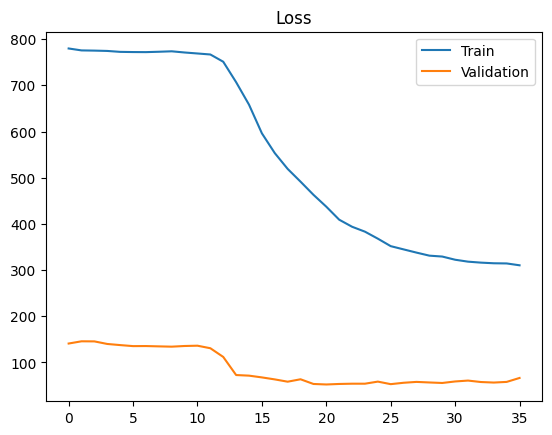

IndexError: index 2000 is out of bounds for axis 0 with size 106

<Figure size 640x480 with 0 Axes>

In [254]:
# Loss curves
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

#example plot
idx = 2000

plt.figure()
plt.plot(price_true[idx], label="Actual Price")
plt.plot(price_pred[idx], label="Predicted Price")
plt.legend()
plt.title("24h Price Forecast Example")
plt.show()
